## Importy bibliotek:

In [1]:
import cv2
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
from skimage.feature import hog
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

%matplotlib inline

## Parametry i ekstrakcja cech HOG 
Dodanie klasy negatywnej (tło), wykorzystanie HOG do wyciagniecia informacji o krawedziach sylwetki.

In [2]:
# Parametry okna i cech HOG (dla zbioru INRIAPerson)
WINDOW_SIZE = (64, 128) # (szerokość, wysokość)
CELL_SIZE = (8, 8)
BLOCK_SIZE = (2, 2)
NBINS = 9

def extract_hog(img):
    """Konwertuje obraz na skalę szarości i wyciąga cechy HOG"""
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = cv2.resize(img, WINDOW_SIZE)
    
    features = hog(img, orientations=NBINS, pixels_per_cell=CELL_SIZE,
                   cells_per_block=BLOCK_SIZE, block_norm='L2-Hys',
                   transform_sqrt=True, feature_vector=True)
    return features

def load_data(pos_path, neg_path):
    features = []
    labels = []
    
    # Ładowanie próbek POZYTYWNYCH (sylwetki) -> Etykieta 1
    pos_files = glob.glob(os.path.join(pos_path, '*.*'))
    for file in pos_files:
        img = cv2.imread(file)
        if img is not None:
            features.append(extract_hog(img))
            labels.append(1)
            
    # Ładowanie próbek NEGATYWNYCH (tło) -> Etykieta 0
    neg_files = glob.glob(os.path.join(neg_path, '*.*'))
    for file in neg_files:
        img = cv2.imread(file)
        if img is not None:
            features.append(extract_hog(img))
            labels.append(0)
            
    return np.array(features), np.array(labels)

## Załadowanie danych i trening klasyfikatora (SVM)

In [3]:
ścieżka_pos = 'pos'              # Folder zawierający pozytywne próbki (sylwetki ludzi)
ścieżka_neg = 'neg_64'           # Folder zawierający negatywne próbki (tło)

print("Ładowanie danych obrazów i ekstrakcja cech HOG...")
X, y = load_data(ścieżka_pos, ścieżka_neg)   # Wczytanie obrazów oraz obliczenie cech HOG

print(f"Załadowano {len(X)} próbek.")        # Wyświetlenie liczby wszystkich próbek

# Podział danych na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,               # 20% danych przeznaczone na test
    random_state=42              # Stałe losowanie dla powtarzalnych wyników
)

# Trenowanie klasyfikatora SVM zamiast prostego porównywania wzorców
print("Trenowanie klasyfikatora Linear SVM...")

clf = LinearSVC(
    C=1.0,                       # Parametr regularyzacji modelu SVM
    max_iter=10000               # Maksymalna liczba iteracji uczenia
)

clf.fit(X_train, y_train)        # Uczenie modelu na danych treningowych

print("Gotowe. Wyniki na zbiorze testowym:")

y_pred = clf.predict(X_test)     # Predykcja klas dla danych testowych

print(classification_report(
    y_test,                      # Prawdziwe etykiety klas
    y_pred                       # Klasy przewidziane przez model
))

Ładowanie danych obrazów i ekstrakcja cech HOG...
Załadowano 5778 próbek.
Trenowanie klasyfikatora Linear SVM...
Gotowe. Wyniki na zbiorze testowym:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       493
           1       0.97      0.96      0.97       663

    accuracy                           0.96      1156
   macro avg       0.96      0.96      0.96      1156
weighted avg       0.96      0.96      0.96      1156



## Struktura Sliding Window

In [4]:
def sliding_window(image, step_size, window_size):
    """Generator zwracający kolejne fragmenty obrazu podczas przesuwania okna."""

    # Przesuwanie okna w pionie co step_size pikseli
    for y in range(0, image.shape[0] - window_size[1], step_size):

        # Przesuwanie okna w poziomie co step_size pikseli
        for x in range(0, image.shape[1] - window_size[0], step_size):

            # Zwrócenie współrzędnych okna oraz wycinka obrazu
            yield (
                x,
                y,
                image[y:y + window_size[1], x:x + window_size[0]]
            )


def detect_pedestrians(image, classifier,
                       window_size=WINDOW_SIZE,
                       step_size=8):

    boxes = []     # Lista wykrytych ramek (bounding boxes)
    scores = []    # Lista confidence score z klasyfikatora SVM

    # Iteracja po wszystkich oknach sliding window
    for (x, y, window) in sliding_window(
            image,
            step_size,
            window_size):

        # Pominięcie okien wychodzących poza obraz
        if window.shape[0] != window_size[1] or \
           window.shape[1] != window_size[0]:
            continue

        # Ekstrakcja cech HOG dla aktualnego okna
        features = extract_hog(window)

        # Obliczenie confidence score klasyfikatora SVM
        score = classifier.decision_function([features])[0]

        # Sprawdzenie czy score przekracza ustalony próg detekcji
        if score > 1.5:

            # Dodanie współrzędnych wykrytej sylwetki
            boxes.append((
                x,
                y,
                x + window_size[0],
                y + window_size[1]
            ))

            # Zapisanie confidence score dla NMS
            scores.append(score)

    # Zwrócenie wykrytych ramek oraz confidence score
    return boxes, scores

## Testowanie na większym obrazie

Testowanie na obrazie z innego zbioru


TEST: people_1.jpg
Szukanie sylwetek...
Liczba ramek przed NMS: 71
Liczba ramek po NMS: 11


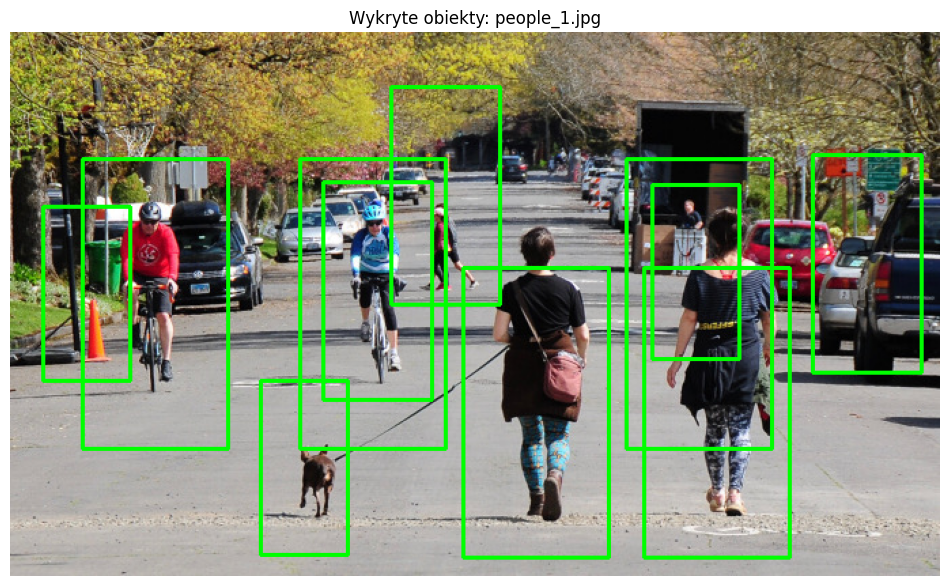


TEST: people_2.jpg
Szukanie sylwetek...
Liczba ramek przed NMS: 61
Liczba ramek po NMS: 11


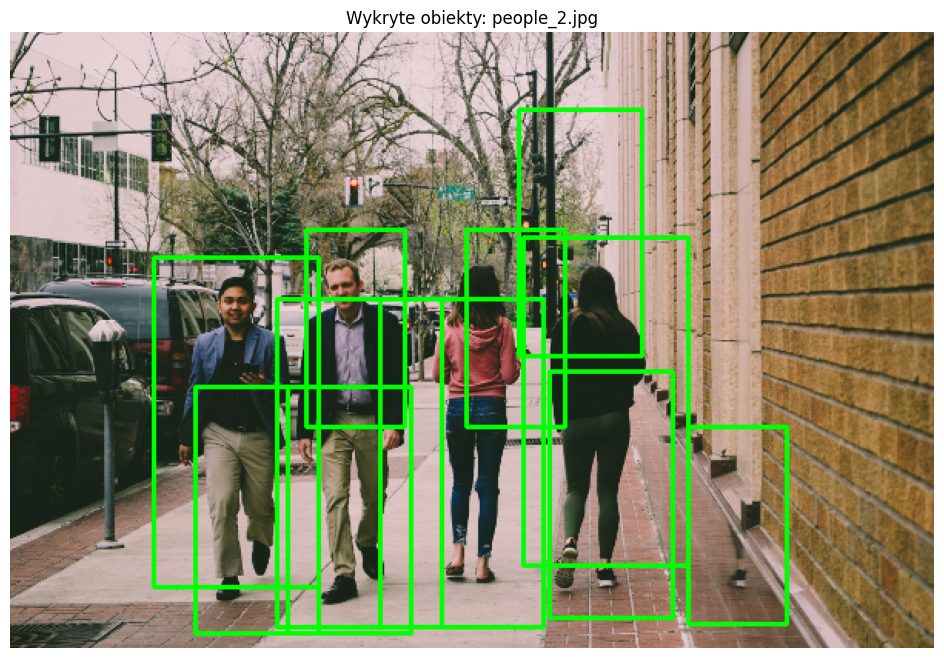


TEST: people_3.jpg
Szukanie sylwetek...
Liczba ramek przed NMS: 15
Liczba ramek po NMS: 5


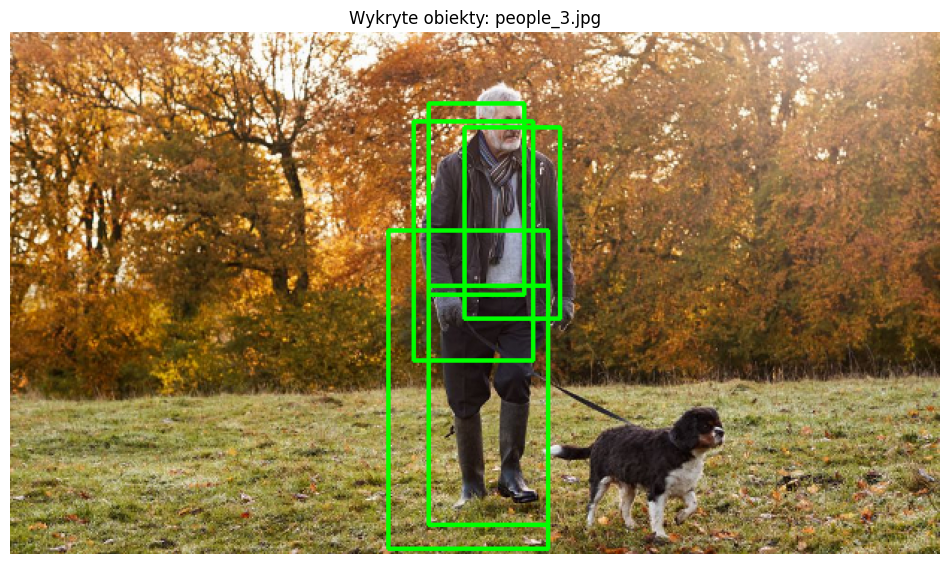


TEST: people_4.jpg
Szukanie sylwetek...
Liczba ramek przed NMS: 4
Liczba ramek po NMS: 3


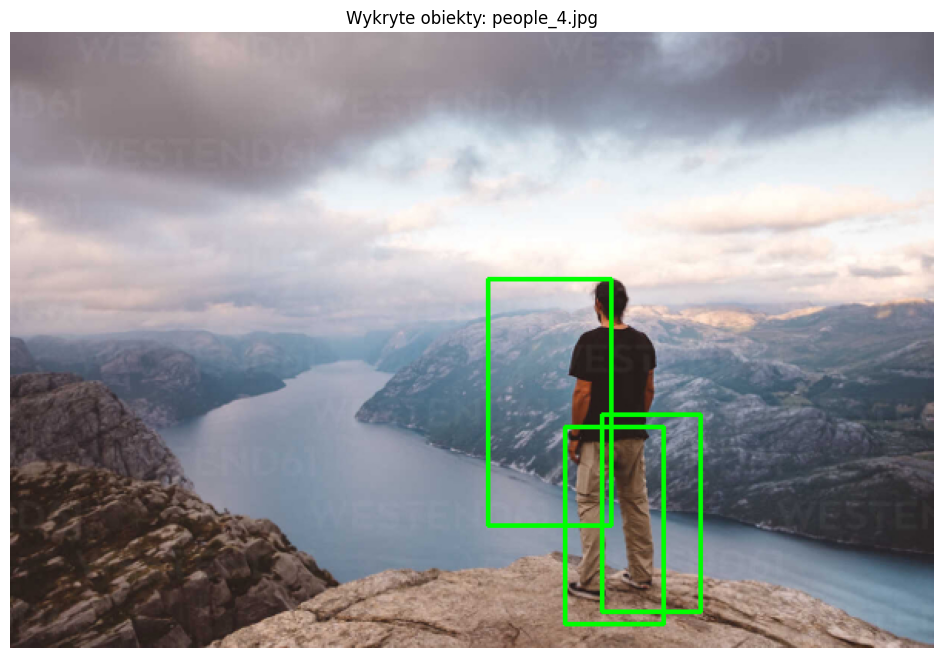

In [6]:
from imutils.object_detection import non_max_suppression
import numpy as np

# Lista obrazów testowych
test_images = [
    'people_1.jpg',
    'people_2.jpg',
    'people_3.jpg',
    'people_4.jpg'
]

# Przetwarzanie każdego obrazu
for test_image_path in test_images:

    print(f"\nTEST: {test_image_path}")

    # Wczytanie obrazu przy pomocy OpenCV
    test_img = cv2.imread(test_image_path)

    # Sprawdzenie czy obraz został poprawnie załadowany
    if test_img is not None:

        clone = test_img.copy()   # Kopia obrazu do rysowania wyników

        print("Szukanie sylwetek...")

        # Lista skal używanych w image pyramid
        scales = [1.0, 0.8, 0.6]

        all_boxes = []    # Lista wszystkich wykrytych ramek
        all_scores = []   # Lista confidence score dla ramek

        # Wykrywanie ludzi dla każdej skali obrazu
        for scale in scales:

            # Skalowanie obrazu
            resized = cv2.resize(
                test_img,
                (0, 0),
                fx=scale,
                fy=scale
            )

            # Uruchomienie detektora sliding window + HOG + SVM
            boxes, scores = detect_pedestrians(
                resized,
                clf,
                window_size=WINDOW_SIZE,
                step_size=8
            )

            # Przeskalowanie ramek do rozmiaru oryginalnego obrazu
            for (box, score) in zip(boxes, scores):

                x1, y1, x2, y2 = box

                all_boxes.append((
                    int(x1 / scale),
                    int(y1 / scale),
                    int(x2 / scale),
                    int(y2 / scale)
                ))

                all_scores.append(score)

        # Sprawdzenie czy wykryto jakiekolwiek ramki
        if len(all_boxes) == 0:
            print("Nie wykryto żadnych sylwetek.")
            continue

        # Konwersja listy ramek do tablicy NumPy
        rects = np.array(all_boxes)

        # Non-Maximum Suppression
        pick = non_max_suppression(
            rects,
            probs=np.array(all_scores),
            overlapThresh=0.6
        )

        print(f"Liczba ramek przed NMS: {len(rects)}")
        print(f"Liczba ramek po NMS: {len(pick)}")

        # Rysowanie końcowych ramek po NMS
        for (startX, startY, endX, endY) in pick:

            cv2.rectangle(
                clone,
                (startX, startY),
                (endX, endY),
                (0, 255, 0),
                2
            )

        # Wyświetlenie obrazu z detekcjami
        plt.figure(figsize=(12, 8))

        plt.imshow(cv2.cvtColor(clone, cv2.COLOR_BGR2RGB))

        plt.title(f"Wykryte obiekty: {test_image_path}")

        plt.axis("off")

        plt.show()

    else:
        print(f"Nie można załadować obrazka: {test_image_path}")